# Conditional VAE for Pull Play Sequence Prediction

Train a Conditional Variational Autoencoder to predict the first 3 throws after a pull,
conditioned on pull landing position and receiving team.

**Architecture:**
- Input: 12 values (3 throws × from_x, from_y, to_x, to_y)
- Condition: pull_x, pull_y + team embedding (8-dim)
- Latent: 6-dimensional
- Loss: MSE reconstruction + β·KL divergence

In [1]:
import psycopg2
from psycopg2.extras import RealDictCursor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import joblib
import os

np.random.seed(42)
torch.manual_seed(42)

print('Setup complete')

Setup complete


## 1. Load Pull Play Sequences

In [2]:
DB_CONFIG = {
    'dbname': 'ufa_analytics',
    'user': os.getenv('DB_USER', 'postgres'),
    'password': '',
    'host': 'localhost',
    'port': 5432
}

def get_db_connection():
    return psycopg2.connect(**DB_CONFIG, cursor_factory=RealDictCursor)

In [3]:
conn = get_db_connection()
cur = conn.cursor()

# Get all 3-throw sequences after pulls with direction normalization
cur.execute("""
    WITH pull_data AS (
        SELECT
            p.game_id, p.event_number AS pull_num,
            CASE WHEN recv.team = g.away_team_id THEN -p.pull_x ELSE p.pull_x END AS pull_x,
            CASE WHEN recv.team = g.away_team_id THEN 120 - p.pull_y ELSE p.pull_y END AS pull_y,
            recv.team AS recv_team,
            CASE WHEN recv.team = g.away_team_id THEN TRUE ELSE FALSE END AS is_away
        FROM events p
        JOIN games g ON p.game_id = g.game_id
        JOIN events recv ON p.game_id = recv.game_id
            AND recv.event_number = p.event_number + 1
            AND recv.event_type IN (18, 19, 20, 22)
        WHERE p.event_type = 7
          AND p.pull_x IS NOT NULL AND p.pull_y IS NOT NULL
    )
    SELECT
        pd.recv_team,
        pd.pull_x, pd.pull_y,
        CASE WHEN pd.is_away THEN -e1.thrower_x ELSE e1.thrower_x END AS t1_fx,
        CASE WHEN pd.is_away THEN 120 - e1.thrower_y ELSE e1.thrower_y END AS t1_fy,
        CASE WHEN pd.is_away THEN -e1.receiver_x ELSE e1.receiver_x END AS t1_tx,
        CASE WHEN pd.is_away THEN 120 - e1.receiver_y ELSE e1.receiver_y END AS t1_ty,
        CASE WHEN pd.is_away THEN -e2.thrower_x ELSE e2.thrower_x END AS t2_fx,
        CASE WHEN pd.is_away THEN 120 - e2.thrower_y ELSE e2.thrower_y END AS t2_fy,
        CASE WHEN pd.is_away THEN -e2.receiver_x ELSE e2.receiver_x END AS t2_tx,
        CASE WHEN pd.is_away THEN 120 - e2.receiver_y ELSE e2.receiver_y END AS t2_ty,
        CASE WHEN pd.is_away THEN -e3.thrower_x ELSE e3.thrower_x END AS t3_fx,
        CASE WHEN pd.is_away THEN 120 - e3.thrower_y ELSE e3.thrower_y END AS t3_fy,
        CASE WHEN pd.is_away THEN -e3.receiver_x ELSE e3.receiver_x END AS t3_tx,
        CASE WHEN pd.is_away THEN 120 - e3.receiver_y ELSE e3.receiver_y END AS t3_ty
    FROM pull_data pd
    JOIN events e1 ON pd.game_id = e1.game_id AND e1.event_number = pd.pull_num + 1
    JOIN events e2 ON pd.game_id = e2.game_id AND e2.event_number = pd.pull_num + 2
    JOIN events e3 ON pd.game_id = e3.game_id AND e3.event_number = pd.pull_num + 3
    WHERE e1.event_type IN (18, 19) AND e1.receiver_x IS NOT NULL
      AND e2.event_type IN (18, 19) AND e2.receiver_x IS NOT NULL
      AND e3.event_type IN (18, 19) AND e3.receiver_x IS NOT NULL
      AND e1.team = e2.team AND e2.team = e3.team
""")

rows = cur.fetchall()
cur.close()
conn.close()

df = pd.DataFrame(rows)
print(f'Total 3-throw sequences: {len(df):,}')
print(f'Unique teams: {df["recv_team"].nunique()}')
print(f'\nSequences per team:')
print(df['recv_team'].value_counts().to_string())

Total 3-throw sequences: 24,024
Unique teams: 29

Sequences per team:
recv_team
mechanix        1136
alleycats       1086
flyers          1057
aviators        1040
thunderbirds    1032
breeze          1031
empire          1031
spiders         1030
cascades        1025
growlers        1014
sol             1009
windchill       1008
phoenix         1000
glory            993
rush             965
hustle           929
union            928
radicals         924
royal            884
steel            882
shred            842
legion           814
apex             773
havoc            583
cannons          419
outlaws          340
bighorns         190
allstars2         31
allstars1         28


## 2. Preprocessing

In [4]:
# Encode teams (reserve index 0 for "all teams")
team_encoder = LabelEncoder()
team_encoder.fit(df['recv_team'])
n_real_teams = len(team_encoder.classes_)

# Team IDs: 1-indexed (0 = all teams pseudo-token)
df['team_encoded'] = team_encoder.transform(df['recv_team']) + 1

print(f'Teams: {n_real_teams}')
print(f'Team mapping: 0=all, {dict(enumerate(team_encoder.classes_, 1))}')

Teams: 29
Team mapping: 0=all, {1: 'alleycats', 2: 'allstars1', 3: 'allstars2', 4: 'apex', 5: 'aviators', 6: 'bighorns', 7: 'breeze', 8: 'cannons', 9: 'cascades', 10: 'empire', 11: 'flyers', 12: 'glory', 13: 'growlers', 14: 'havoc', 15: 'hustle', 16: 'legion', 17: 'mechanix', 18: 'outlaws', 19: 'phoenix', 20: 'radicals', 21: 'royal', 22: 'rush', 23: 'shred', 24: 'sol', 25: 'spiders', 26: 'steel', 27: 'thunderbirds', 28: 'union', 29: 'windchill'}


In [5]:
# Normalize coordinates to [0, 1]
# x: [-25, 25] -> [0, 1]
# y: [0, 120] -> [0, 1]

throw_cols = ['t1_fx', 't1_tx', 't2_fx', 't2_tx', 't3_fx', 't3_tx']  # x coords
throw_y_cols = ['t1_fy', 't1_ty', 't2_fy', 't2_ty', 't3_fy', 't3_ty']  # y coords

for col in throw_cols:
    df[col + '_norm'] = (df[col].astype(float) + 25) / 50
for col in throw_y_cols:
    df[col + '_norm'] = df[col].astype(float) / 120

df['pull_x_norm'] = (df['pull_x'].astype(float) + 25) / 50
df['pull_y_norm'] = df['pull_y'].astype(float) / 120

# Build target array: 12 values per sequence
# Order: t1_fx, t1_fy, t1_tx, t1_ty, t2_fx, t2_fy, t2_tx, t2_ty, t3_fx, t3_fy, t3_tx, t3_ty
target_cols = [
    't1_fx_norm', 't1_fy_norm', 't1_tx_norm', 't1_ty_norm',
    't2_fx_norm', 't2_fy_norm', 't2_tx_norm', 't2_ty_norm',
    't3_fx_norm', 't3_fy_norm', 't3_tx_norm', 't3_ty_norm',
]

sequences = df[target_cols].values.astype(np.float32)
pull_positions = df[['pull_x_norm', 'pull_y_norm']].values.astype(np.float32)
team_ids = df['team_encoded'].values.astype(np.int64)

# Clip to [0, 1] for safety
sequences = np.clip(sequences, 0, 1)
pull_positions = np.clip(pull_positions, 0, 1)

print(f'Sequences shape: {sequences.shape}')
print(f'Pull positions shape: {pull_positions.shape}')
print(f'Team IDs range: {team_ids.min()} to {team_ids.max()}')
print(f'\nTarget stats:')
print(f'  Min: {sequences.min():.3f}, Max: {sequences.max():.3f}')
print(f'  Mean: {sequences.mean():.3f}, Std: {sequences.std():.3f}')

Sequences shape: (24024, 12)
Pull positions shape: (24024, 2)
Team IDs range: 1 to 29

Target stats:
  Min: 0.000, Max: 1.000
  Mean: 0.395, Std: 0.229


In [6]:
# Create "all teams" duplicates (team_id=0) for every sequence
all_team_ids = np.zeros(len(team_ids), dtype=np.int64)

sequences_full = np.concatenate([sequences, sequences], axis=0)
pull_positions_full = np.concatenate([pull_positions, pull_positions], axis=0)
team_ids_full = np.concatenate([team_ids, all_team_ids], axis=0)

print(f'Total samples (with all-teams duplicates): {len(sequences_full):,}')
print(f'  Team-specific: {len(sequences):,}')
print(f'  All-teams: {len(sequences):,}')

Total samples (with all-teams duplicates): 48,048
  Team-specific: 24,024
  All-teams: 24,024


In [7]:
# Train/test split
idx = np.arange(len(sequences_full))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42)

seq_train = torch.FloatTensor(sequences_full[idx_train])
pull_train = torch.FloatTensor(pull_positions_full[idx_train])
team_train = torch.LongTensor(team_ids_full[idx_train])

seq_test = torch.FloatTensor(sequences_full[idx_test])
pull_test = torch.FloatTensor(pull_positions_full[idx_test])
team_test = torch.LongTensor(team_ids_full[idx_test])

train_dataset = TensorDataset(seq_train, pull_train, team_train)
test_dataset = TensorDataset(seq_test, pull_test, team_test)

BATCH_SIZE = 256
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train: {len(seq_train):,} samples ({len(train_loader)} batches)')
print(f'Test: {len(seq_test):,} samples ({len(test_loader)} batches)')

Train: 38,438 samples (151 batches)
Test: 9,610 samples (38 batches)


## 3. Model Definition

In [ ]:
class PullPlayCVAE(nn.Module):
    """
    Conditional VAE for pull play sequences.
    
    Condition: pull landing (x, y) + team embedding
    Input/Output: 12-dim throw sequence (3 throws x 4 coords)
    """
    def __init__(self, n_teams, seq_dim=12, latent_dim=16, 
                 team_embed_dim=8, condition_dim=16, hidden_dim=128):
        super().__init__()
        self.latent_dim = latent_dim
        self.seq_dim = seq_dim
        
        # Team embedding (n_teams + 1 for the "all teams" token at index 0)
        self.team_embedding = nn.Embedding(n_teams + 1, team_embed_dim)
        
        # Condition network: (pull_x, pull_y, team_embed) -> condition vector
        self.condition_net = nn.Sequential(
            nn.Linear(2 + team_embed_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, condition_dim)
        )
        
        # Encoder: (sequence + condition) -> mu, log_var
        self.encoder = nn.Sequential(
            nn.Linear(seq_dim + condition_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_log_var = nn.Linear(hidden_dim, latent_dim)
        
        # Decoder layers (with skip from z to intermediate layer)
        self.decoder_fc1 = nn.Sequential(
            nn.Linear(latent_dim + condition_dim, hidden_dim),
            nn.ReLU(),
        )
        self.decoder_fc2 = nn.Sequential(
            nn.Linear(hidden_dim + latent_dim, hidden_dim),  # z skip
            nn.ReLU(),
        )
        self.decoder_out = nn.Sequential(
            nn.Linear(hidden_dim, seq_dim),
            nn.Sigmoid()
        )
    
    def get_condition(self, pull_pos, team_ids):
        """Process conditioning inputs."""
        team_emb = self.team_embedding(team_ids)
        combined = torch.cat([pull_pos, team_emb], dim=1)
        return self.condition_net(combined)
    
    def encode(self, x, condition):
        """Encode sequence to latent distribution."""
        h = self.encoder(torch.cat([x, condition], dim=1))
        return self.fc_mu(h), self.fc_log_var(h)
    
    def reparameterize(self, mu, log_var):
        """Reparameterization trick."""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z, condition):
        """Decode latent + condition to sequence (z injected at two layers)."""
        h = self.decoder_fc1(torch.cat([z, condition], dim=1))
        h = self.decoder_fc2(torch.cat([h, z], dim=1))  # skip
        return self.decoder_out(h)
    
    def forward(self, x, pull_pos, team_ids):
        """Full forward pass."""
        condition = self.get_condition(pull_pos, team_ids)
        mu, log_var = self.encode(x, condition)
        z = self.reparameterize(mu, log_var)
        x_recon = self.decode(z, condition)
        return x_recon, mu, log_var
    
    def sample(self, pull_pos, team_ids, n_samples=1):
        """Sample sequences from the prior."""
        self.eval()
        with torch.no_grad():
            condition = self.get_condition(pull_pos, team_ids)
            condition = condition.repeat(n_samples, 1)
            z = torch.randn(n_samples, self.latent_dim)
            return self.decode(z, condition)


def cvae_loss(x_recon, x, mu, log_var, beta=1.0, free_bits=0.5):
    """
    CVAE loss: reconstruction + beta * KL divergence.
    Free bits: each latent dim must use at least `free_bits` nats of KL
    to prevent posterior collapse.
    """
    recon_loss = nn.functional.mse_loss(x_recon, x, reduction='mean')
    # Per-dimension KL, clamped from below (free bits)
    kl_per_dim = -0.5 * (1 + log_var - mu.pow(2) - log_var.exp())  # [B, D]
    kl_loss = torch.clamp(kl_per_dim, min=free_bits).sum(dim=1).mean()
    return recon_loss + beta * kl_loss, recon_loss, kl_loss


In [ ]:
# Create model
LATENT_DIM = 16      # Larger latent space for more play variety
HIDDEN_DIM = 128
CONDITION_DIM = 16
TEAM_EMBED_DIM = 8
FREE_BITS = 0.5      # Minimum KL per latent dim (prevents posterior collapse)
BETA_MAX = 1.0       # Final beta value
BETA_WARMUP = 100    # Epochs to linearly ramp beta from 0 to BETA_MAX
LEARNING_RATE = 0.001
EPOCHS = 400

model = PullPlayCVAE(
    n_teams=n_real_teams,
    seq_dim=12,
    latent_dim=LATENT_DIM,
    team_embed_dim=TEAM_EMBED_DIM,
    condition_dim=CONDITION_DIM,
    hidden_dim=HIDDEN_DIM,
)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params:,}')
print(f'Latent dim: {LATENT_DIM}')
print(f'Free bits per dim: {FREE_BITS}  (min total KL: {FREE_BITS * LATENT_DIM:.1f})')
print(f'Beta warmup: {BETA_WARMUP} epochs -> {BETA_MAX}')


## 4. Training

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.7, patience=20, min_lr=1e-6
)

train_losses = []
val_losses = []
train_recon_losses = []
train_kl_losses = []
beta_log = []
best_val_loss = float('inf')
patience_counter = 0
early_stop_patience = 40

print(f"{'Epoch':>6} | {'Beta':>6} | {'Train':>10} | {'Recon':>10} | {'KL':>10} | {'Val':>10} | {'LR':>10}")
print('-' * 82)

for epoch in range(EPOCHS):
    # KL annealing: linearly ramp beta from 0 to BETA_MAX over BETA_WARMUP epochs
    beta = min(BETA_MAX, BETA_MAX * epoch / max(BETA_WARMUP, 1))
    beta_log.append(beta)

    # Train
    model.train()
    epoch_loss = 0
    epoch_recon = 0
    epoch_kl = 0
    
    for batch_seq, batch_pull, batch_team in train_loader:
        optimizer.zero_grad()
        x_recon, mu, log_var = model(batch_seq, batch_pull, batch_team)
        loss, recon, kl = cvae_loss(x_recon, batch_seq, mu, log_var,
                                    beta=beta, free_bits=FREE_BITS)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        epoch_loss += loss.item()
        epoch_recon += recon.item()
        epoch_kl += kl.item()
    
    train_loss = epoch_loss / len(train_loader)
    train_recon = epoch_recon / len(train_loader)
    train_kl = epoch_kl / len(train_loader)
    train_losses.append(train_loss)
    train_recon_losses.append(train_recon)
    train_kl_losses.append(train_kl)
    
    # Validate (beta=1 for consistent comparison)
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_seq, batch_pull, batch_team in test_loader:
            x_recon, mu, log_var = model(batch_seq, batch_pull, batch_team)
            loss, _, _ = cvae_loss(x_recon, batch_seq, mu, log_var,
                                   beta=1.0, free_bits=FREE_BITS)
            val_loss += loss.item()
    
    val_loss /= len(test_loader)
    val_losses.append(val_loss)
    
    # Step scheduler on recon loss only (not total, to avoid beta scaling effects)
    scheduler.step(train_recon)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
    
    if (epoch + 1) % 20 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f'{epoch+1:6d} | {beta:6.3f} | {train_loss:10.6f} | {train_recon:10.6f} | {train_kl:10.6f} | {val_loss:10.6f} | {lr:10.7f}')
    
    if patience_counter >= early_stop_patience and beta >= BETA_MAX:
        print(f'\nEarly stopping at epoch {epoch+1}')
        model.load_state_dict(best_state)
        break

print(f'\nBest validation loss: {best_val_loss:.6f}')


## 5. Training Curves

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(train_losses, label='Train', linewidth=2)
axes[0].plot(val_losses, label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('CVAE Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_recon_losses, label='Reconstruction (MSE)', linewidth=2, color='tab:blue')
axes[1].plot(train_kl_losses, label='KL (per dim, free bits clamped)', linewidth=2, color='tab:orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss Component')
axes[1].set_title('Loss Components')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(beta_log, linewidth=2, color='tab:green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Beta')
axes[2].set_title('KL Beta Schedule')
axes[2].set_ylim(0, BETA_MAX * 1.1)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cvae_training_curve.png', dpi=150)
plt.show()

# Check that latent space is actually being used
model.eval()
with torch.no_grad():
    sample_pull = torch.FloatTensor([[(0 + 25) / 50, 20 / 120]])
    sample_team = torch.LongTensor([0])
    samples_1000 = model.sample(sample_pull, sample_team, n_samples=1000).numpy()

sample_std = samples_1000.std(axis=0)
x_std_yds = sample_std[[0,2,4,6,8,10]] * 50
y_std_yds = sample_std[[1,3,5,7,9,11]] * 120
print('Sample diversity (should be >> 0 now):')
for t in range(3):
    print(f'  Throw {t+1}: x_std={x_std_yds[t]:.1f}yd, y_std={y_std_yds[t]:.1f}yd')


In [ ]:
## 5b. Find Common Play Archetypes via Latent Clustering
# Encode all sequences -> cluster their latent codes -> decode cluster centers

from sklearn.cluster import KMeans

N_CLUSTERS = 6

model.eval()

# Encode all training sequences to get latent means
all_mus = []
with torch.no_grad():
    for batch_seq, batch_pull, batch_team in train_loader:
        condition = model.get_condition(batch_pull, batch_team)
        mu, _ = model.encode(batch_seq, condition)
        all_mus.append(mu.numpy())

all_mus = np.vstack(all_mus)  # [N_train, LATENT_DIM]
print(f'Encoded {len(all_mus):,} sequences to latent space')
print(f'Latent mean std per dim: {all_mus.std(axis=0).mean():.3f}  (>0.5 means z is being used)')

# K-Means on latent codes
km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
km.fit(all_mus)
cluster_labels = km.labels_
cluster_counts = np.bincount(cluster_labels)
print(f'\nCluster sizes: {sorted(cluster_counts, reverse=True)}')

# Decode each cluster center (conditioned on neutral: center pull, all-teams)
pull_x_neutral = (0 + 25) / 50   # center field
pull_y_neutral = 20 / 120          # 20 yards deep
neutral_pull = torch.FloatTensor([[pull_x_neutral, pull_y_neutral]])
neutral_team = torch.LongTensor([0])  # all teams

cluster_seqs = []
with torch.no_grad():
    condition = model.get_condition(neutral_pull, neutral_team)
    for center in km.cluster_centers_:
        z = torch.FloatTensor(center).unsqueeze(0)
        cond_rep = condition.repeat(z.shape[0], 1)
        decoded = model.decode(z, cond_rep).numpy()[0]
        cluster_seqs.append(decoded)

# Visualize all clusters on one field
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

colors = ['#3b82f6', '#22c55e', '#f97316', '#ec4899', '#a855f7', '#eab308']

def denormalize_sequence(seq):
    result = seq.copy()
    for i in [0, 2, 4, 6, 8, 10]:  # x coords
        result[i] = result[i] * 50 - 25
    for i in [1, 3, 5, 7, 9, 11]:  # y coords
        result[i] = result[i] * 120
    return result

for c_idx, (ax, decoded) in enumerate(zip(axes, cluster_seqs)):
    seq = denormalize_sequence(decoded)
    pct = cluster_counts[c_idx] / cluster_counts.sum() * 100
    
    ax.set_xlim(0, 120)
    ax.set_ylim(-27, 27)
    ax.set_facecolor('#2a5934')
    ax.axvline(x=20, color='white', linestyle='--', alpha=0.4)
    ax.axvline(x=100, color='white', linestyle='--', alpha=0.4)
    ax.axvline(x=60, color='white', linestyle=':', alpha=0.25)
    
    throw_colors = ['#ffffff', '#ffdd00', '#ff4444']
    for t in range(3):
        fx = seq[t*4 + 1]; fy = seq[t*4 + 0]
        tx = seq[t*4 + 3]; ty = seq[t*4 + 2]
        ax.annotate('', xy=(tx, ty), xytext=(fx, fy),
                   arrowprops=dict(arrowstyle='->', color=throw_colors[t],
                                  lw=2.5, mutation_scale=18))
        ax.plot(fx, fy, 'o', color=throw_colors[t], markersize=5)
    
    # Pull landing at center
    ax.plot(20, 0, 'c^', markersize=10, zorder=10,
            markeredgecolor='white', markeredgewidth=1.5)
    
    ax.set_title(f'Pattern {c_idx+1}  ({pct:.0f}% of plays)',
                 color='white', fontsize=12, fontweight='bold')
    ax.set_xlabel('Field Y (attack →)', color='#aaa', fontsize=9)
    ax.tick_params(colors='white', labelsize=8)
    fig.patch.set_facecolor('#1a1a2e')
    ax.spines[:].set_color('#444')

fig.suptitle('Common 3-Throw Patterns After Pull (K-Means on CVAE Latent Space)',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nPattern summary:')
for i, (seq, cnt) in enumerate(zip(cluster_seqs, cluster_counts)):
    s = denormalize_sequence(seq)
    pct = cnt / cluster_counts.sum() * 100
    print(f'Pattern {i+1} ({pct:.0f}%):')
    for t in range(3):
        fx, fy, tx, ty = s[t*4], s[t*4+1], s[t*4+2], s[t*4+3]
        print(f'  Throw {t+1}: ({fx:+.0f}x, {fy:.0f}y) -> ({tx:+.0f}x, {ty:.0f}y)  [+{ty-fy:.0f}y depth]')


## 6. Test Predictions

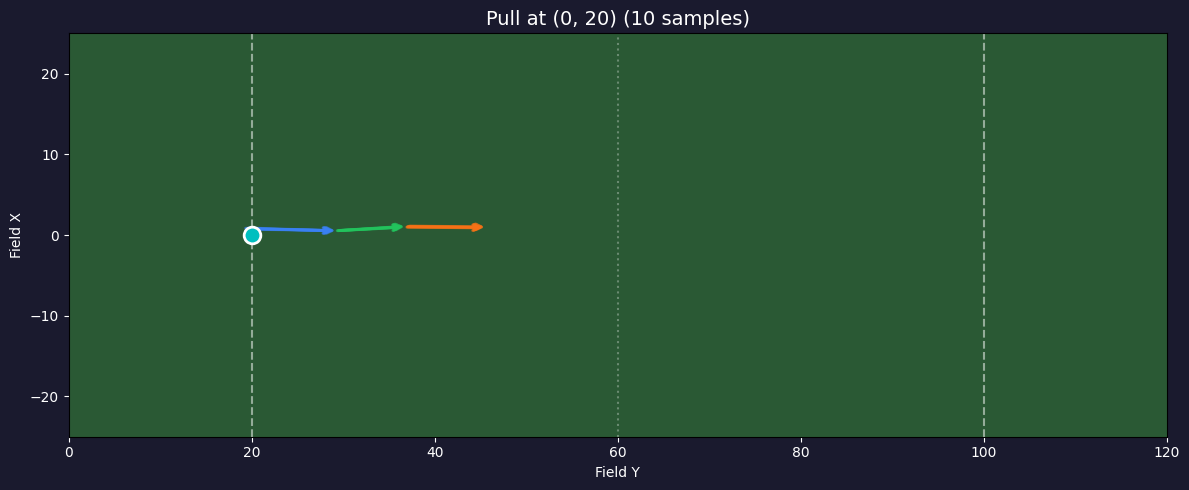

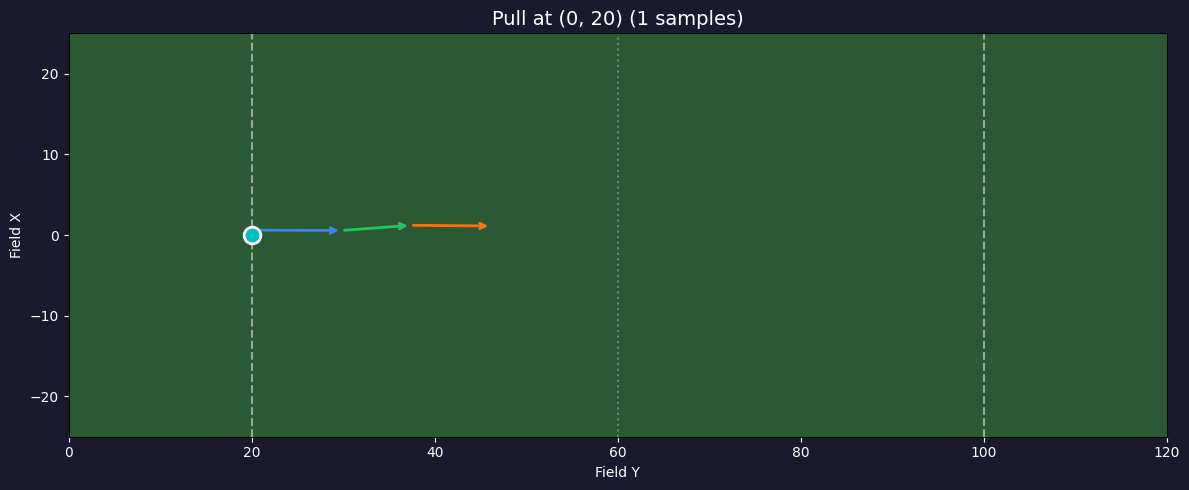

In [12]:
def denormalize_sequence(seq):
    """Convert normalized [0,1] sequence back to field coordinates."""
    result = seq.copy()
    # x coords (indices 0, 2, 4, 6, 8, 10): [0,1] -> [-25, 25]
    for i in [0, 2, 4, 6, 8, 10]:
        result[i] = result[i] * 50 - 25
    # y coords (indices 1, 3, 5, 7, 9, 11): [0,1] -> [0, 120]
    for i in [1, 3, 5, 7, 9, 11]:
        result[i] = result[i] * 120
    return result


def visualize_samples(pull_x, pull_y, team_name=None, n_samples=10):
    """Visualize sampled sequences on field."""
    pull_x_norm = (pull_x + 25) / 50
    pull_y_norm = pull_y / 120
    pull_tensor = torch.FloatTensor([[pull_x_norm, pull_y_norm]])
    
    if team_name:
        team_id = team_encoder.transform([team_name])[0] + 1
    else:
        team_id = 0  # all teams
    team_tensor = torch.LongTensor([team_id])
    
    samples = model.sample(pull_tensor, team_tensor, n_samples=n_samples).numpy()
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Draw field
    ax.set_xlim(0, 120)
    ax.set_ylim(-25, 25)
    ax.set_facecolor('#2a5934')
    ax.axvline(x=20, color='white', linestyle='--', alpha=0.5)
    ax.axvline(x=100, color='white', linestyle='--', alpha=0.5)
    ax.axvline(x=60, color='white', linestyle=':', alpha=0.3)
    
    colors = ['#3b82f6', '#22c55e', '#f97316']
    
    for s in range(n_samples):
        seq = denormalize_sequence(samples[s])
        alpha = 0.4 if n_samples > 1 else 1.0
        
        for t in range(3):
            fx = seq[t*4 + 1]  # from_y (horizontal on plot)
            fy = seq[t*4 + 0]  # from_x (vertical on plot)
            tx = seq[t*4 + 3]  # to_y
            ty = seq[t*4 + 2]  # to_x
            ax.annotate('', xy=(tx, ty), xytext=(fx, fy),
                       arrowprops=dict(arrowstyle='->', color=colors[t], lw=2, alpha=alpha))
    
    # Pull landing
    ax.plot(pull_y, pull_x, 'co', markersize=12, zorder=10, markeredgecolor='white', markeredgewidth=2)
    
    title = f'Pull at ({pull_x:.0f}, {pull_y:.0f})'
    if team_name:
        title += f' - {team_name}'
    title += f' ({n_samples} samples)'
    ax.set_title(title, color='white', fontsize=14)
    ax.set_xlabel('Field Y', color='white')
    ax.set_ylabel('Field X', color='white')
    ax.tick_params(colors='white')
    fig.patch.set_facecolor('#1a1a2e')
    plt.tight_layout()
    plt.show()


# Test: all teams, pull at center
visualize_samples(0, 20, n_samples=10)
visualize_samples(0, 20, n_samples=1)

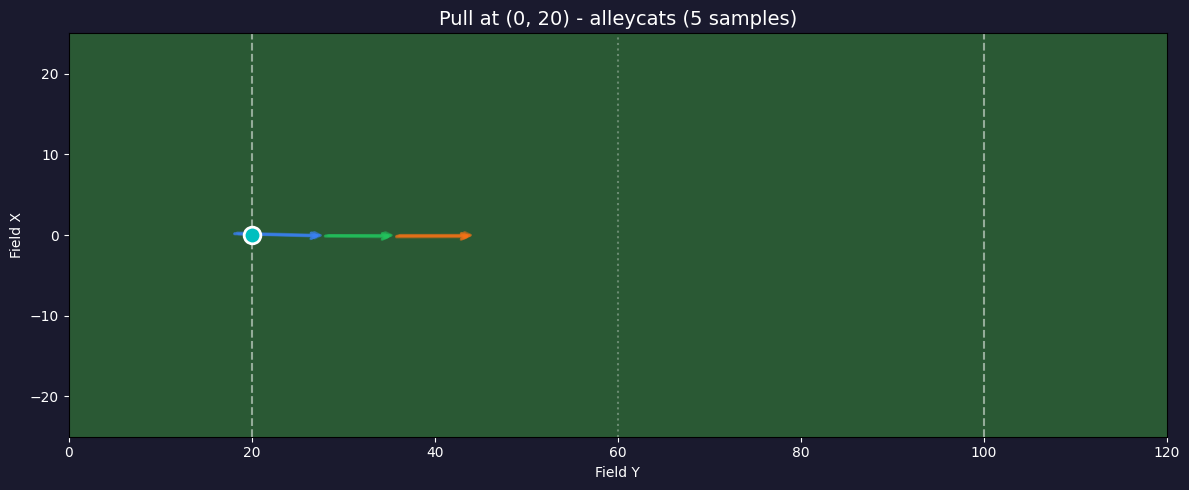

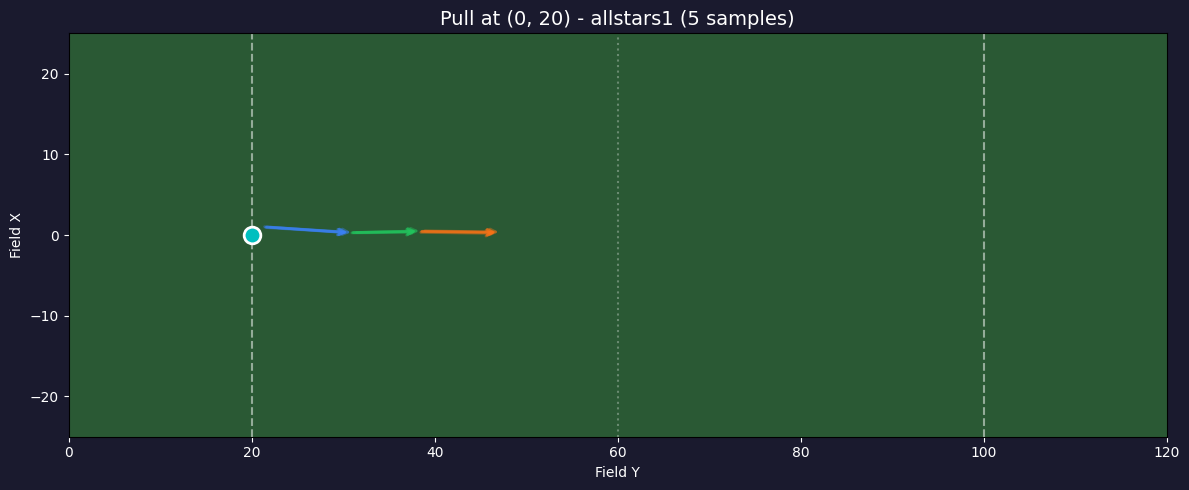

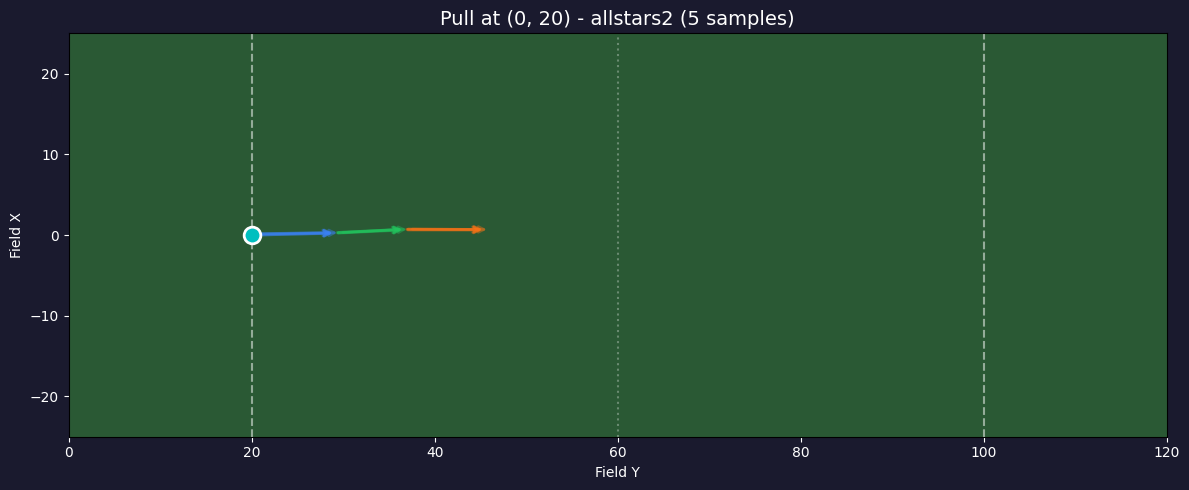

In [13]:
# Test team-specific predictions
teams_to_test = team_encoder.classes_[:3]
for t in teams_to_test:
    visualize_samples(0, 20, team_name=t, n_samples=5)

In [14]:
# Compare model mean vs data average
model.eval()
pull_tensor = torch.FloatTensor([[(0 + 25) / 50, 20 / 120]])
team_tensor = torch.LongTensor([0])

# Generate many samples and average
many_samples = model.sample(pull_tensor, team_tensor, n_samples=1000).numpy()
model_mean = denormalize_sequence(many_samples.mean(axis=0))

print('Model mean sequence (from 1000 samples):')
for i in range(3):
    fx, fy, tx, ty = model_mean[i*4:(i+1)*4]
    print(f'  Throw {i+1}: ({fx:.1f}, {fy:.1f}) -> ({tx:.1f}, {ty:.1f})')

print('\nModel sample std:')
sample_std = many_samples.std(axis=0)
for i in range(3):
    print(f'  Throw {i+1}: x_std={sample_std[i*4]*50:.1f}yd, y_std={sample_std[i*4+1]*120:.1f}yd')

Model mean sequence (from 1000 samples):
  Throw 1: (0.8, 19.3) -> (0.5, 29.3)
  Throw 2: (0.5, 29.3) -> (1.0, 36.9)
  Throw 3: (1.0, 36.9) -> (1.0, 45.6)

Model sample std:
  Throw 1: x_std=0.1yd, y_std=0.3yd
  Throw 2: x_std=0.0yd, y_std=0.2yd
  Throw 3: x_std=0.1yd, y_std=0.2yd


In [18]:
os.makedirs('models', exist_ok=True)

save_dict = {
    'model_state_dict': best_state,
    'team_encoder': team_encoder,
    'n_real_teams': n_real_teams,
    'hyperparameters': {
        'seq_dim': 12,
        'latent_dim': LATENT_DIM,
        'team_embed_dim': TEAM_EMBED_DIM,
        'condition_dim': CONDITION_DIM,
        'hidden_dim': HIDDEN_DIM,
        'beta_max': BETA_MAX,
        'free_bits': FREE_BITS,
    },
    'train_losses': train_losses,
    'val_losses': val_losses,
    'best_val_loss': best_val_loss,
    # Cluster archetypes (K-Means on latent space)
    'kmeans': km,
    'n_clusters': N_CLUSTERS,
    'cluster_seqs_normalized': np.array(cluster_seqs),  # [K, 12] in [0,1]
    'cluster_counts': cluster_counts,
}

joblib.dump(save_dict, 'models/pull_play_cvae.pkl')
print('Model saved to models/pull_play_cvae.pkl')
print(f'File size: {os.path.getsize("models/pull_play_cvae.pkl") / 1024:.1f} KB')
print(f'Includes {N_CLUSTERS} cluster archetypes')


Model saved to models/pull_play_cvae.pkl
File size: 363.2 KB
Includes 6 cluster archetypes
